# Milestone 2 Deep Analysis

This notebook supports the corrected project direction: second-degree connection value in the Last.fm UK friendship graph.

## Scope note

The local files support second-degree matching via **age group** and **country**. The intended music-taste layer is still part of the final vision, but it requires a user-level listening table that is not present in the current workspace.

In [1]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
summary = json.loads((ROOT / "data" / "analysis_summary.json").read_text(encoding="utf-8"))

overview = pd.DataFrame(summary["overview"].items(), columns=["metric", "value"])
quality = pd.DataFrame(summary["quality_checks"].items(), columns=["check", "value"])
age_groups = pd.DataFrame(summary["charts"]["age_group_distribution"])
countries = pd.DataFrame(summary["charts"]["top_countries"])
degree_hist = pd.DataFrame(summary["charts"]["degree_histogram"])
second_hist = pd.DataFrame(summary["charts"]["second_degree_histogram"])
shared_hist = pd.DataFrame(summary["charts"]["shared_attribute_histogram"])
case_sizes = pd.DataFrame(summary["charts"]["prototype_case_sizes"])

In [2]:
display(overview)
display(quality)

,metric,value
0,users,76778
1,connected_users,75969
2,unique_friendships,389639
3,median_degree,5
4,median_second_degree,166


,check,value
0,missing_age,14952
1,missing_country,9
2,missing_gender,277
3,users_with_degree_zero,809


In [3]:
for idx, caveat in enumerate(summary["caveats"], start=1):
    print(f"{idx}. {caveat}")

1. The local workspace contains user demographics and the friendship graph, so age-group and country matching can be implemented directly.
2. The local workspace does not contain a user-to-artist listening table, so music-taste matching cannot yet be computed at the user level from the available files alone.
3. For that reason, the corrected prototype implements real second-degree filtering for age group and country, and reserves music-taste filtering as a documented next step if the listening-history file is added.


## Core findings

In [4]:
for idx, insight in enumerate(summary["insights"], start=1):
    print(f"{idx}. {insight}")

1. The cleaned graph contains 389,639 unique undirected friendships across 75,969 connected users.
2. The median user has 5 direct friends but 166 second-degree candidates, which supports the core idea that the real opportunity lies beyond the first hop.
3. Second-degree opportunity scales quickly: the 90th percentile user reaches 1,542 friends-of-friends after excluding direct ties.
4. Attribute overlap remains meaningful in the second-degree layer: the median user has 43 second-degree candidates sharing both country and age group.
5. The dataset is overwhelmingly UK-based, so country matching is informative for prototype logic but should not be over-interpreted as geographic diversity.


## User composition

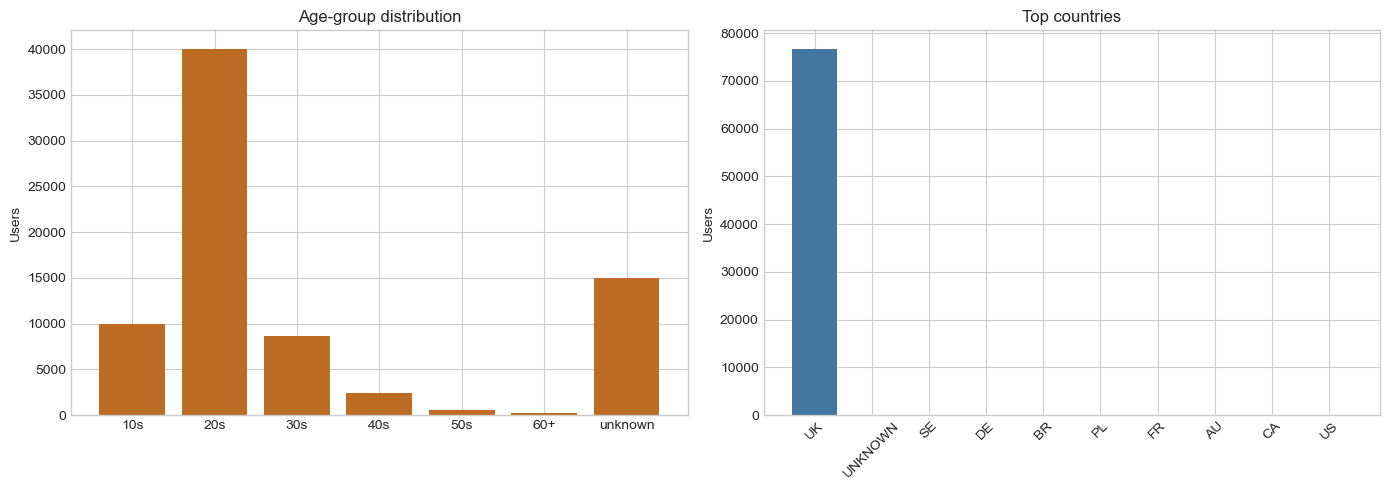

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_groups["label"], age_groups["value"], color="#bc6c25")
axes[0].set_title("Age-group distribution")
axes[0].set_ylabel("Users")

axes[1].bar(countries["label"], countries["value"], color="#4377a2")
axes[1].set_title("Top countries")
axes[1].set_ylabel("Users")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## From first-degree to second-degree

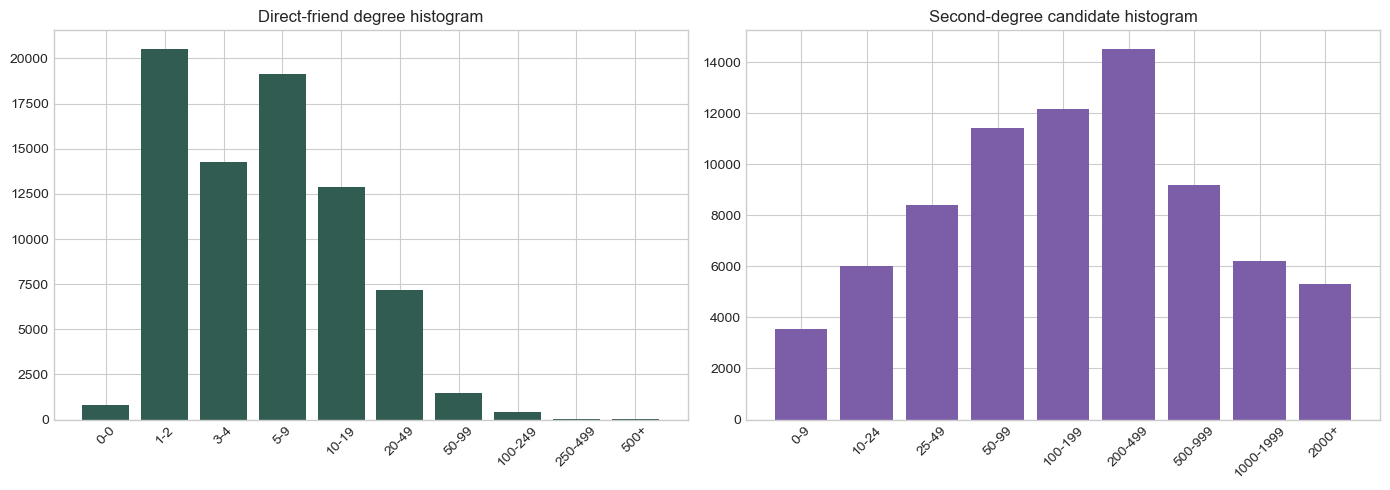

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(degree_hist["label"], degree_hist["value"], color="#315c52")
axes[0].set_title("Direct-friend degree histogram")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(second_hist["label"], second_hist["value"], color="#7b5ea7")
axes[1].set_title("Second-degree candidate histogram")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The right-hand plot is the conceptual heart of the project. It shows why the second-degree layer is worth exploring at all: the reachable social space is much larger than the direct-friend layer.

## Shared-trait opportunity

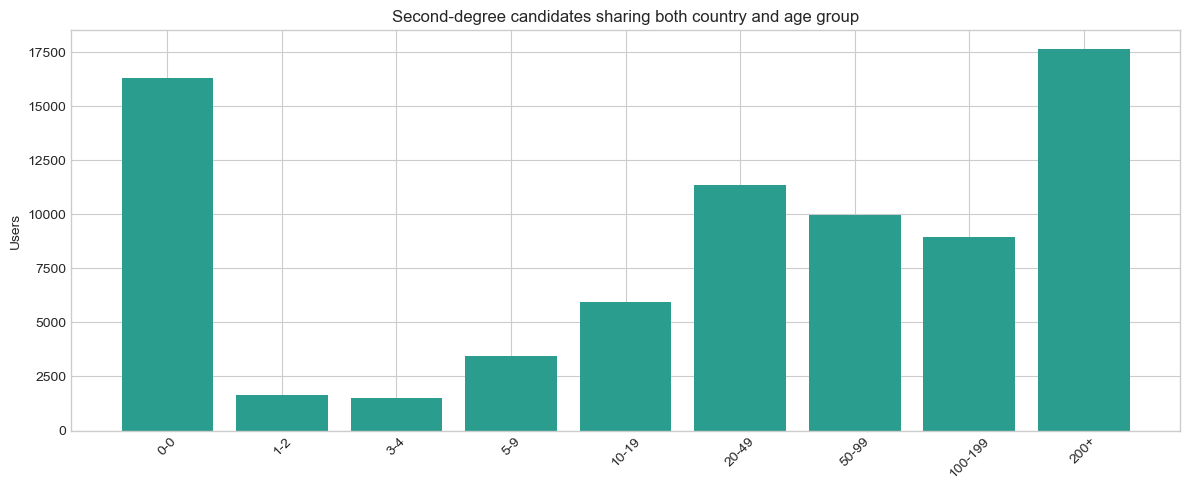

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(shared_hist["label"], shared_hist["value"], color="#2a9d8f")
ax.set_title("Second-degree candidates sharing both country and age group")
ax.set_ylabel("Users")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

This distribution is what turns the project into more than a graph display. The second-degree layer is still broad, but a meaningful subset survives once we ask which candidates actually resemble the ego user.

## Prototype case studies

In [8]:
display(case_sizes)

,label,direct_friends,second_degree_count,same_country_second_degree,same_age_group_second_degree
0,User 46455,11,216,16,15
1,User 60013,14,200,16,13
2,User 41599,15,194,16,16


In [9]:
cases = summary["prototype"]["cases"]
for case in cases:
    print(f"User {case['user']['id']} | direct friends: {case['summary']['direct_friends']} | total second degree: {case['summary']['second_degree_count']}")
    candidate_table = pd.DataFrame(case["candidates"]).sort_values(
        ["shared_attribute_count", "mutual_friends", "degree"],
        ascending=[False, False, False],
    ).head(6)
    display(candidate_table)

User 46455 | direct friends: 11 | total second degree: 216


,id,label,country,age_group,degree,mutual_friends,same_country,same_age_group,shared_attribute_count
0,67974,User 67974,UK,20s,24,4,True,True,2
1,44702,User 44702,UK,20s,78,2,True,True,2
2,26989,User 26989,UK,20s,12,2,True,True,2
3,43687,User 43687,UK,20s,10,2,True,True,2
4,73750,User 73750,UK,20s,6,2,True,True,2
6,51398,User 51398,UK,20s,1643,1,True,True,2


User 60013 | direct friends: 14 | total second degree: 200


,id,label,country,age_group,degree,mutual_friends,same_country,same_age_group,shared_attribute_count
0,10639,User 10639,UK,10s,199,5,True,True,2
1,47859,User 47859,UK,10s,74,3,True,True,2
2,45853,User 45853,UK,10s,22,3,True,True,2
6,19775,User 19775,UK,10s,76,2,True,True,2
7,66775,User 66775,UK,10s,60,2,True,True,2
8,12023,User 12023,UK,10s,58,2,True,True,2


User 41599 | direct friends: 15 | total second degree: 194


,id,label,country,age_group,degree,mutual_friends,same_country,same_age_group,shared_attribute_count
0,67881,User 67881,UK,20s,38,2,True,True,2
1,18614,User 18614,UK,20s,24,2,True,True,2
2,10616,User 10616,UK,20s,12,2,True,True,2
3,46753,User 46753,UK,20s,9,2,True,True,2
4,25967,User 25967,UK,20s,9,2,True,True,2
5,57313,User 57313,UK,20s,9,2,True,True,2


## Design implications

1. The first screen of the final product must show expansion from first degree to second degree.
2. Filters are not optional decoration: they are the mechanism that turns a large reachable layer into meaningful social opportunities.
3. Candidate ranking should combine shared-attribute overlap with mutual-friend count.
4. Music-taste matching should be implemented only when the necessary listening table is available, not invented from incomplete metadata.